# TSMC: bounded GPU XGBoost forecasting experiment

Predict the next observed trading day's **unadjusted closing price in USD**, from information available after today's close. Compare three prespecified feature sets under the **same four hyperparameter combinations: 12 tuning fits and one final refit**, run sequentially on CUDA. A separate two-tree synthetic probe checks GPU support; it is not a forecasting candidate.

The tree model learns `Target_Close - Close`, a dollar correction to today's known price. Add that correction to `Close` for price forecasts. Squared dollar-change error equals squared reconstructed-price error. This avoids requiring tree leaf values to extrapolate the whole price level, and parallels the persistence connection in the neural notebooks. It does not guarantee skill over persistence. We do not additionally search alternative target definitions.

Preserve the project's chronological 70/15/15 boundaries and common complete rows. Validation chooses both boosting duration and the winning configuration; test is used only after these are locked. This reuse of one validation period is a limitation. No trading or profitability claims are made.

GPU training uses `tree_method='hist', device='cuda:0'`, checked in the fitted booster configuration. The notebook stops if CUDA is unavailable; it does not silently train on CPU. Preprocessing and plotting use the CPU. Requires XGBoost >=2.0 with CUDA support, NumPy, pandas, scikit-learn, Matplotlib and Jupyter.

## 1. Reproducible configuration and GPU verification

Use four combinations of depth {2, 3} and learning rate {0.03, 0.10}. All other parameters are fixed, including regularization, sampling, seed, and a maximum of 300 boosting rounds with 25-round patience. Shallow trees and a small search keep this experiment practical on the RTX 3050. GPU overhead may dominate on this small dataset; GPU use does not promise a speedup.


In [1]:
from pathlib import Path
from datetime import datetime, timezone
import json, time, hashlib, platform, warnings, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from IPython.display import display, Markdown

if int(xgb.__version__.split('.')[0]) < 2:
    raise RuntimeError('Use CUDA-enabled XGBoost >=2.0 in this Jupyter kernel.')
SEED = 42
TRAIN_FRACTION, VALIDATION_FRACTION = 0.70, 0.15
MAX_ROUNDS, PATIENCE = 300, 25
GRID = [{'max_depth': depth, 'eta': rate} for depth in (2, 3) for rate in (0.03, 0.10)]
COMMON_PARAMS = dict(objective='reg:squarederror', eval_metric='rmse',
                     tree_method='hist', device='cuda:0', nthread=2,
                     seed=SEED, base_score=0.0, min_child_weight=10,
                     reg_lambda=10.0, reg_alpha=0.0, subsample=0.8,
                     colsample_bytree=1.0, max_bin=128, verbosity=1)

def verify_gpu(booster):
    config = json.loads(booster.save_config())
    device = config['learner']['generic_param']['device']
    if not device.startswith('cuda'):
        raise RuntimeError(f'GPU training required; XGBoost used {device}. Check the kernel and CUDA build.')
    return device

probe_x = np.arange(64, dtype=np.float32).reshape(32, 2)
probe = xgb.train({**COMMON_PARAMS, 'max_depth': 2},
                  xgb.DMatrix(probe_x, label=np.sin(probe_x[:, 0]), nthread=2),
                  num_boost_round=2)
print('Verified device:', verify_gpu(probe), '| XGBoost:', xgb.__version__)
del probe, probe_x

ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / 'Data' / 'TSMC_Master_Features_15Y.csv').is_file()), None)
if ROOT is None:
    raise FileNotFoundError('Run from the project directory or a child directory.')
DATA_FILE = ROOT / 'Data' / 'TSMC_Master_Features_15Y.csv'
RUN_ID = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ')
RUN_DIR = ROOT / 'models' / 'xgboost' / RUN_ID
PLOT_DIR = RUN_DIR / 'plots'
PLOT_DIR.mkdir(parents=True, exist_ok=False)
plt.style.use('seaborn-v0_8-whitegrid')

def finish_plot(name):
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f'{name}.png', dpi=140, bbox_inches='tight')
    plt.show()
    plt.close()

display(pd.DataFrame(GRID))
print('12 candidates, at most 300 rounds each; outputs:', RUN_DIR)


Verified device: cuda:0 | XGBoost: 3.2.0


,max_depth,eta
0,2,0.03
1,2,0.10
2,3,0.03
3,3,0.10


12 candidates, at most 300 rounds each; outputs: F:\SEM-7\Time Series Analysis\Project\models\xgboost\20260927T040834645810Z


## 2. Audit the source and trailing features

The master CSV comes from the project's local Yahoo Finance data; `validate.ipynb` contains Google comparisons. These checks verify local consistency, not vendor authenticity. Retain source/download metadata in the report. Check dates, OHLC consistency and every engineered feature against present/past-only calculations. Do not backfill warm-up rows.


In [2]:
raw = pd.read_csv(DATA_FILE)
raw['Date'] = pd.to_datetime(raw['Date'], errors='raise')
raw = raw.sort_values('Date').reset_index(drop=True)
assert raw['Date'].notna().all() and raw['Date'].is_unique, 'Missing or duplicate dates.'
assert raw['Date'].is_monotonic_increasing
numeric_columns = raw.columns.drop('Date').tolist()
raw[numeric_columns] = raw[numeric_columns].apply(pd.to_numeric, errors='raise')
assert not np.isinf(raw[numeric_columns].to_numpy()).any(), 'Infinite data values.'
assert (raw['Close'] > 0).all() and (raw['Volume'] >= 0).all()
tol = 1e-5
assert (raw['High'] + tol >= raw[['Open', 'Close', 'Low']].max(axis=1)).all()
assert (raw['Low'] - tol <= raw[['Open', 'Close', 'High']].min(axis=1)).all()

expected = {
    'Log_Close': np.log(raw['Close']),
    'Return_1D': raw['Close'].pct_change(fill_method=None),
    'Log_Return_1D': np.log(raw['Close']).diff(),
    'High_Low_Range': (raw['High'] - raw['Low']) / raw['Close'],
    'Open_Close_Change': (raw['Close'] - raw['Open']) / raw['Open'],
    'Day_of_Week': raw['Date'].dt.dayofweek,
    'Month': raw['Date'].dt.month, 'Quarter': raw['Date'].dt.quarter,
    'Year': raw['Date'].dt.year,
}
for lag in [1, 2, 3, 5, 10, 20]:
    expected[f'Close_Lag_{lag}'] = raw['Close'].shift(lag)
    expected[f'Return_Lag_{lag}'] = expected['Return_1D'].shift(lag)
for window in [5, 10, 20, 50]:
    expected[f'SMA_{window}'] = raw['Close'].rolling(window).mean()
for window in [5, 10, 20]:
    expected[f'Volatility_{window}'] = expected['Log_Return_1D'].rolling(window).std()
    expected[f'Momentum_{window}D'] = raw['Close'].pct_change(window, fill_method=None)
for name, values in expected.items():
    np.testing.assert_allclose(raw[name], values, rtol=1e-6, atol=1e-8,
                               equal_nan=True, err_msg=f'Feature mismatch: {name}')

audit = pd.DataFrame({'dtype': raw.dtypes.astype(str), 'missing': raw.isna().sum()})
display(audit)
print(f'{len(raw):,} rows; {len(raw.columns)} columns; '
      f"{raw['Date'].min().date()} through {raw['Date'].max().date()}")
print('Verified all engineered columns against causal trailing calculations.')
audit.to_csv(RUN_DIR / 'data_audit.csv')


,dtype,missing
Date,datetime64[ns],0
Open,float64,0
High,float64,0
Low,float64,0
Close,float64,0
Adj Close,float64,0
Volume,int64,0
Log_Close,float64,0
Return_1D,float64,1
Log_Return_1D,float64,1


3,771 rows; 38 columns; 2011-09-12 through 2026-09-10
Verified all engineered columns against causal trailing calculations.


## 3. Three feature sets and common chronological splits

* **all_features:** the same 36 usable columns as ARIMAX, excluding Date and Adj Close.
* **curated:** the same eight prespecified ARIMAX inputs: returns, range, intraday change, volatility, momentum and volume.
* **close_history:** Close and six existing close lags (1, 2, 3, 5, 10, 20). Trees do not have ARIMA's internal temporal state, so explicit close lags provide the price-history comparison. This is not an identical input representation to ARIMA.

The curated set is fixed in advance, not selected from test performance. The all-feature set retains ordinal calendar fields, including Year, for consistency with ARIMAX; redundant features and calendar representation are limitations. Current Close is also the reconstruction anchor for every variant, even when not a tree input in the curated set.

Drop the same incomplete rows for all variants before splitting. Keep the next-day price target for reporting and derive the dollar-change training label separately.


In [3]:
EXCLUDED = {'Date': 'Index only', 'Adj Close': 'Point-in-time adjustment unavailable'}
ALL_ORIGINAL_FEATURES = [c for c in numeric_columns if c != 'Adj Close']
FEATURES = ALL_ORIGINAL_FEATURES
FEATURE_SETS = {
    'all_features': FEATURES,
    'curated': ['Return_1D', 'Return_Lag_1', 'Return_Lag_5', 'High_Low_Range',
                'Open_Close_Change', 'Volatility_20', 'Momentum_5D', 'Volume'],
    'close_history': ['Close'] + [f'Close_Lag_{lag}' for lag in (1, 2, 3, 5, 10, 20)],
}
aligned = raw.rename(columns={'Date': 'Origin_Date'}).copy()
aligned['Target_Date'] = aligned['Origin_Date'].shift(-1)
aligned['Target_Close'] = aligned['Close'].shift(-1)
data = aligned.dropna(subset=ALL_ORIGINAL_FEATURES + ['Target_Date', 'Target_Close']).reset_index(drop=True)
assert len(data) > 500 and data['Target_Date'].is_unique
assert (data['Origin_Date'] < data['Target_Date']).all()
train_end = int(len(data) * TRAIN_FRACTION)
validation_end = int(len(data) * (TRAIN_FRACTION + VALIDATION_FRACTION))
train = data.iloc[:train_end].copy()
validation = data.iloc[train_end:validation_end].copy()
test = data.iloc[validation_end:].copy()
assert train['Target_Date'].max() < validation['Target_Date'].min()
assert validation['Target_Date'].max() < test['Target_Date'].min()
assert train['Target_Date'].iloc[-1] <= validation['Origin_Date'].iloc[0]
assert validation['Target_Date'].iloc[-1] <= test['Origin_Date'].iloc[0]

split_summary = pd.DataFrame([
    {'split': name, 'rows': len(frame),
     'first_origin': frame['Origin_Date'].min(), 'last_origin': frame['Origin_Date'].max(),
     'first_target': frame['Target_Date'].min(), 'last_target': frame['Target_Date'].max()}
    for name, frame in [('train', train), ('validation', validation), ('test', test)]])
display(split_summary)
display(data[['Origin_Date', 'Close', 'Target_Date', 'Target_Close']].head())
print('Features:', FEATURES)
print('Raw rows:', len(raw), '| usable aligned observations:', len(data))
split_summary.to_csv(RUN_DIR / 'splits.csv', index=False)

(RUN_DIR / 'features.json').write_text(json.dumps(FEATURE_SETS, indent=2), encoding='utf-8')
display(pd.DataFrame([{'feature_set': key, 'count': len(value), 'features': ', '.join(value)}
                      for key, value in FEATURE_SETS.items()]))


,split,rows,first_origin,last_origin,first_target,last_target
0,train,2604,2011-11-18,2022-03-25,2011-11-21,2022-03-28
1,validation,558,2022-03-28,2024-06-14,2022-03-29,2024-06-17
2,test,559,2024-06-17,2026-09-09,2024-06-18,2026-09-10


,Origin_Date,Close,Target_Date,Target_Close
0,2011-11-18,12.66,2011-11-21,12.56
1,2011-11-21,12.56,2011-11-22,12.56
2,2011-11-22,12.56,2011-11-23,12.20
3,2011-11-23,12.20,2011-11-25,12.07
4,2011-11-25,12.07,2011-11-28,12.55


Features: ['Open', 'High', 'Low', 'Close', 'Volume', 'Log_Close', 'Return_1D', 'Log_Return_1D', 'High_Low_Range', 'Open_Close_Change', 'Close_Lag_1', 'Close_Lag_2', 'Close_Lag_3', 'Close_Lag_5', 'Close_Lag_10', 'Close_Lag_20', 'Return_Lag_1', 'Return_Lag_2', 'Return_Lag_3', 'Return_Lag_5', 'Return_Lag_10', 'Return_Lag_20', 'SMA_5', 'SMA_10', 'SMA_20', 'SMA_50', 'Volatility_5', 'Volatility_10', 'Volatility_20', 'Momentum_5D', 'Momentum_10D', 'Momentum_20D', 'Day_of_Week', 'Month', 'Quarter', 'Year']
Raw rows: 3771 | usable aligned observations: 3721


,feature_set,count,features
0,all_features,36,"Open, High, Low, Close, Volume, Log_Close, Ret..."
1,curated,8,"Return_1D, Return_Lag_1, Return_Lag_5, High_Lo..."
2,close_history,7,"Close, Close_Lag_1, Close_Lag_2, Close_Lag_3, ..."


## 4. Minimal preprocessing and evaluation helpers

Tree splits do not require standardization or normalization. Use finite float32 inputs in a saved feature order; no scaler, clipping, imputation, or volume log transform is needed. Common-row removal has already handled missing warm-up values. Dollar-change labels are computed before conversion to float32.

Persistence predicts no change. Report price MAE/MSE/RMSE/MAPE/R², MASE and improvement over persistence. Also report up/down/flat signal counts and an always-up direction reference: high direction accuracy can simply reflect positive predictions every day. Direction diagnostics are not trading returns.


In [4]:
def make_matrix(frame, columns, labels=False):
    values = frame.loc[:, columns].to_numpy(dtype=np.float32)
    if not np.isfinite(values).all():
        raise ValueError('Non-finite feature values.')
    label = (frame['Target_Close'] - frame['Close']).to_numpy(dtype=np.float32) if labels else None
    return xgb.DMatrix(values, label=label, feature_names=list(columns), nthread=2)

def price_prediction(booster, frame, columns, rounds=None):
    matrix = make_matrix(frame, columns)
    kwargs = {} if rounds is None else {'iteration_range': (0, rounds)}
    delta = booster.predict(matrix, **kwargs).astype(np.float64)
    return frame['Close'].to_numpy(dtype=np.float64) + delta

def score(frame, predictions, fit_frame):
    actual = frame['Target_Close'].to_numpy(dtype=np.float64)
    predicted = np.asarray(predictions, dtype=np.float64)
    origin = frame['Close'].to_numpy(dtype=np.float64)
    assert actual.shape == predicted.shape and np.isfinite(predicted).all()
    mae = float(mean_absolute_error(actual, predicted))
    mse = float(mean_squared_error(actual, predicted))
    rmse = float(np.sqrt(mse))
    persistence_rmse = float(np.sqrt(mean_squared_error(actual, origin)))
    scale = float(np.mean(np.abs(fit_frame['Target_Close'] - fit_frame['Close'])))
    if persistence_rmse <= 0 or scale <= 0:
        raise ValueError('Degenerate persistence baseline.')
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse,
            'MAPE_pct': float(np.mean(np.abs((actual - predicted) / actual)) * 100),
            'R2': float(r2_score(actual, predicted)), 'MASE': mae / scale,
            'Direction_accuracy_pct': float(np.mean(np.sign(predicted - origin) == np.sign(actual - origin)) * 100),
            'RMSE_skill_pct': (1 - rmse / persistence_rmse) * 100}


def direction_diagnostics(frame, predictions):
    predicted = np.sign(np.asarray(predictions) - frame['Close'].to_numpy())
    actual = np.sign(frame['Target_Close'].to_numpy() - frame['Close'].to_numpy())
    return {'predicted_up': int((predicted > 0).sum()),
            'predicted_down': int((predicted < 0).sum()),
            'predicted_flat': int((predicted == 0).sum()),
            'always_up_accuracy_pct': float((actual > 0).mean() * 100)}

baseline_validation = score(validation, validation['Close'].to_numpy(), train)
print('Validation persistence RMSE:', baseline_validation['RMSE'])


Validation persistence RMSE: 2.2316583838383823


## 5. Bounded shared-grid validation on GPU

Train all 12 candidates sequentially on the training period. Validation controls early stopping and ranks candidates; it never enters gradient fitting. Use only the best iteration for predictions, rather than the extra patience rounds. Save every candidate's status, warnings, learning curve and predictions. GPU fallback aborts the experiment; other failed candidates are recorded and cannot win.

Choose lowest validation price RMSE, then MAE, fewer rounds, and candidate name. Keep the best XGBoost model even if persistence wins, and report that outcome honestly. The best score is a selection statistic, not an unbiased estimate after tuning.


In [5]:
records, validation_predictions, curves = [], {}, {}
for feature_set, columns in FEATURE_SETS.items():
    dtrain = make_matrix(train, columns, labels=True)
    dvalid = make_matrix(validation, columns, labels=True)
    for grid_index, params in enumerate(GRID):
        candidate = f'{feature_set}_g{grid_index}'
        row = dict(candidate=candidate, feature_set=feature_set, grid_index=grid_index,
                   n_features=len(columns), **params, status='failed', error='', warnings='')
        started = time.perf_counter()
        caught = []
        try:
            learning = {}
            with warnings.catch_warnings(record=True) as caught:
                warnings.simplefilter('always')
                booster = xgb.train({**COMMON_PARAMS, **params}, dtrain,
                                    num_boost_round=MAX_ROUNDS,
                                    evals=[(dtrain, 'train'), (dvalid, 'validation')],
                                    early_stopping_rounds=PATIENCE,
                                    evals_result=learning, verbose_eval=False)
            device = verify_gpu(booster)
            rounds = int(booster.best_iteration + 1)
            predictions = price_prediction(booster, validation, columns, rounds)
            row.update(status='ok', device=device, best_rounds=rounds,
                       trained_rounds=len(learning['train']['rmse']),
                       **score(validation, predictions, train),
                       **direction_diagnostics(validation, predictions))
            validation_predictions[candidate] = predictions
            curves[candidate] = learning
            del booster
        except RuntimeError:
            raise  # Explicit GPU verification failures must not be hidden.
        except Exception as exc:
            row['error'] = f'{type(exc).__name__}: {exc}'
        finally:
            row['warnings'] = ' | '.join(str(w.message) for w in caught)
            row['seconds'] = time.perf_counter() - started
            records.append(row)
            pd.DataFrame(records).to_csv(RUN_DIR / 'validation_grid.csv', index=False)
            (RUN_DIR / 'learning_curves.json').write_text(json.dumps(curves, indent=2), encoding='utf-8')
        print(candidate, row['status'], 'RMSE:', row.get('RMSE'), flush=True)
    del dtrain, dvalid
    gc.collect()

results = pd.DataFrame(records)
eligible = results[results['status'].eq('ok')].copy()
if eligible.empty:
    raise RuntimeError('No successful candidates; inspect validation_grid.csv.')
eligible = eligible.sort_values(['RMSE', 'MAE', 'best_rounds', 'candidate'])
winner = eligible.iloc[0]
SELECTED_FEATURE_SET = str(winner['feature_set'])
SELECTED_FEATURES = FEATURE_SETS[SELECTED_FEATURE_SET]
SELECTED_PARAMS = GRID[int(winner['grid_index'])]
FINAL_ROUNDS = int(winner['best_rounds'])
display(eligible[['candidate', 'n_features', 'best_rounds', 'RMSE', 'MAE', 'RMSE_skill_pct',
                  'Direction_accuracy_pct', 'predicted_up', 'predicted_down']])
best_by_set = eligible.groupby('feature_set', sort=False).head(1)
best_by_set.to_csv(RUN_DIR / 'validation_best_by_configuration.csv', index=False)
validation_export = validation[['Origin_Date', 'Target_Date', 'Close', 'Target_Close']].copy()
validation_export['Persistence'] = validation['Close'].to_numpy()
for name, predictions in validation_predictions.items():
    validation_export[name] = predictions
validation_export.to_csv(RUN_DIR / 'validation_predictions.csv', index=False)
print('Locked winner:', winner['candidate'], '| rounds:', FINAL_ROUNDS)
print('Beats validation persistence:', bool(winner['RMSE'] < baseline_validation['RMSE']))


all_features_g0 ok RMSE: 2.232724506466925


all_features_g1

 ok RMSE: 2.2357180006944155


all_features_g2 ok RMSE: 2.234361581346011


all_features_g3 ok RMSE: 2.2414309835985446


...

close_history_g1 ok RMSE: 2.2355658730429138


close_history_g2 ok RMSE: 2.2327789845029766


close_history_g3 ok RMSE: 2.236070663525675


,candidate,n_features,best_rounds,RMSE,MAE,RMSE_skill_pct,Direction_accuracy_pct,predicted_up,predicted_down
4,curated_g0,8,1,2.231761,1.607127,-0.004582,48.924731,523,35
5,curated_g1,8,1,2.232035,1.607309,-0.016897,48.924731,523,35
6,curated_g2,8,2,2.232144,1.607338,-0.021783,47.311828,486,72
8,close_history_g0,7,1,2.232695,1.607707,-0.046435,47.670251,468,90
0,all_features_g0,36,1,2.232725,1.607641,-0.047773,47.670251,468,90
10,close_history_g2,7,1,2.232779,1.607903,-0.050214,47.670251,468,90
7,curated_g3,8,1,2.233508,1.606521,-0.082902,48.566308,533,25
2,all_features_g2,36,1,2.234362,1.608857,-0.121130,45.161290,448,110
9,close_history_g1,7,1,2.235566,1.609198,-0.175094,47.670251,468,90
1,all_features_g1,36,1,2.235718,1.609183,-0.181910,47.670251,468,90


Locked winner: curated_g0 | rounds: 1
Beats validation persistence: False


## 6. Refit the locked winner and save a portable model

Fit the selected feature set and parameters on train + validation for exactly the chosen number of rounds. No test labels, early stopping, or test-driven substitutions enter this fit. Weights stay fixed during test; each forecast uses the information available at its own origin.

Save native UBJSON and plain JSON preprocessing metadata, including the dollar-change target and Close reconstruction anchor. Gain importance describes training splits, not causality; correlated features can share or displace importance.


In [6]:
history = pd.concat([train, validation], ignore_index=True)
started = time.perf_counter()
final_model = xgb.train({**COMMON_PARAMS, **SELECTED_PARAMS},
                        make_matrix(history, SELECTED_FEATURES, labels=True),
                        num_boost_round=FINAL_ROUNDS)
final_seconds = time.perf_counter() - started
verified_device = verify_gpu(final_model)
MODEL_FILE = RUN_DIR / 'selected_model.ubj'
final_model.save_model(MODEL_FILE)
preprocessing = {'features': SELECTED_FEATURES, 'input_dtype': 'float32',
                 'scaling': None, 'imputation': None, 'volume_transform': None,
                 'training_target': 'Target_Close - Close',
                 'prediction_reconstruction': 'Close + predicted_dollar_change',
                 'required_anchor': 'Close', 'rounds': FINAL_ROUNDS}
(RUN_DIR / 'preprocessing.json').write_text(json.dumps(preprocessing, indent=2), encoding='utf-8')
(RUN_DIR / 'booster_config.json').write_text(final_model.save_config(), encoding='utf-8')
gains = final_model.get_score(importance_type='gain')
importance = pd.DataFrame({'feature': SELECTED_FEATURES,
                           'gain': [gains.get(f, 0.0) for f in SELECTED_FEATURES]})
importance.sort_values('gain', ascending=False).to_csv(RUN_DIR / 'feature_importance.csv', index=False)
print('Final fit:', verified_device, '| rounds:', FINAL_ROUNDS, '| seconds:', final_seconds)


Final fit: cuda:0 | rounds: 1 | seconds: 0.010330400000384543


## 7. Reserved test evaluation and saved-model reload check

Evaluate only the locked winner and persistence on the common test dates. Report the always-up direction reference explicitly. A high R² or small RMSE improvement does not establish directional skill or profitable trading. No settings change based on these outputs.


In [7]:
test_predictions = price_prediction(final_model, test, SELECTED_FEATURES)
test_metrics = pd.DataFrame({
    'XGBoost_selected': score(test, test_predictions, history),
    'Persistence': score(test, test['Close'].to_numpy(), history),
}).T
test_metrics.index.name = 'model'
display(test_metrics)
test_metrics.to_csv(RUN_DIR / 'test_metrics.csv')
directions = direction_diagnostics(test, test_predictions)
display(pd.DataFrame([directions]))
(RUN_DIR / 'direction_diagnostics.json').write_text(json.dumps(directions, indent=2), encoding='utf-8')
test_export = test[['Origin_Date', 'Target_Date', 'Close', 'Target_Close']].copy()
test_export['Prediction'] = test_predictions
test_export['Persistence'] = test['Close'].to_numpy()
test_export['Error_actual_minus_predicted'] = test_export['Target_Close'] - test_predictions
test_export['Predicted_return'] = test_predictions / test_export['Close'] - 1
test_export['Actual_return'] = test_export['Target_Close'] / test_export['Close'] - 1
test_export.to_csv(RUN_DIR / 'test_predictions.csv', index=False)

reloaded = xgb.Booster()
reloaded.load_model(MODEL_FILE)
reloaded.set_param({'device': 'cpu', 'nthread': 2})
saved_prep = json.loads((RUN_DIR / 'preprocessing.json').read_text(encoding='utf-8'))
reloaded_prices = price_prediction(reloaded, test, saved_prep['features'])
np.testing.assert_allclose(reloaded_prices, test_predictions, rtol=1e-7, atol=1e-5)
print('Portable saved-model check passed on every test row (CPU reload versus GPU-trained model).')


,MAE,MSE,RMSE,MAPE_pct,R2,MASE,Direction_accuracy_pct,RMSE_skill_pct
model,,,,,,,,
XGBoost_selected,5.232285,54.770183,7.400688,1.967761,0.993494,6.609863,53.309481,0.00787
Persistence,5.232576,54.778805,7.401270,1.967970,0.993493,6.610230,0.178891,0.00000


,predicted_up,predicted_down,predicted_flat,always_up_accuracy_pct
0,538,21,0,53.13059


Portable saved-model check passed on every test row (CPU reload versus GPU-trained model).


## 8. Inspect errors, movements and learning curves

Price overlays can conceal weak movement forecasts. Include a recent close-up, rolling error versus persistence, predicted versus actual returns, and signal counts alongside price plots. The training/validation learning curve belongs to the selected tuning fit, not the final refit. These diagnostics do not trigger test-guided retuning.


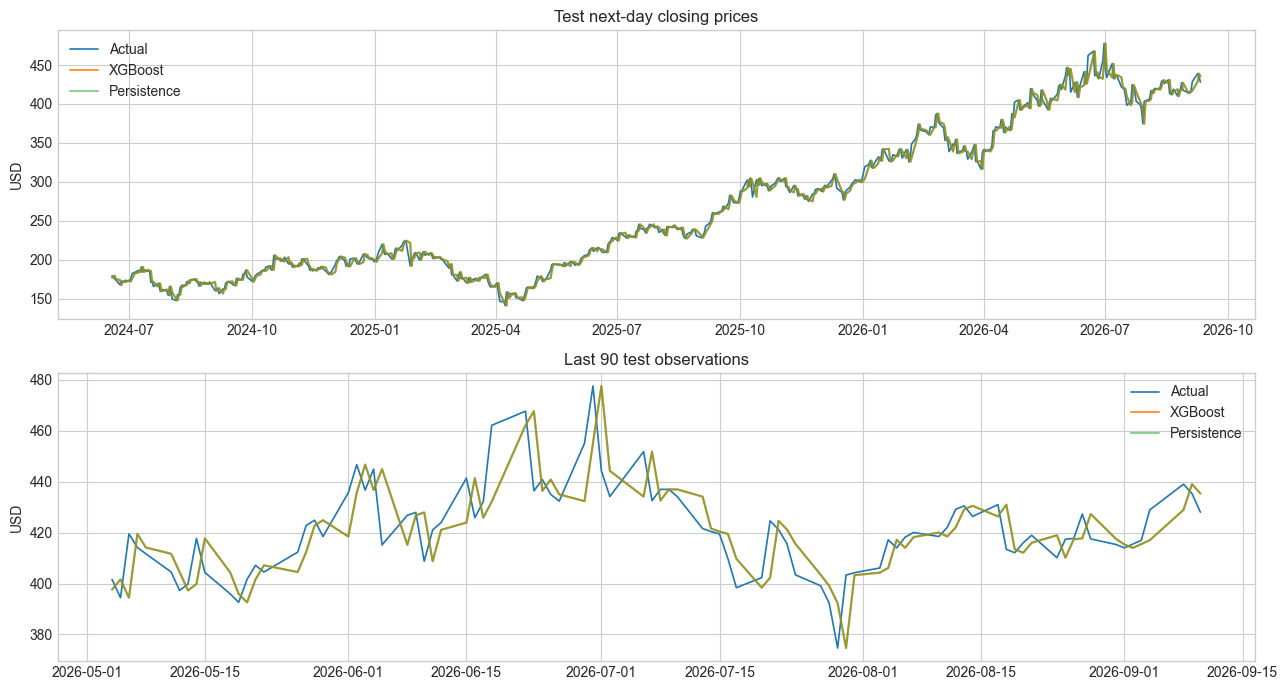

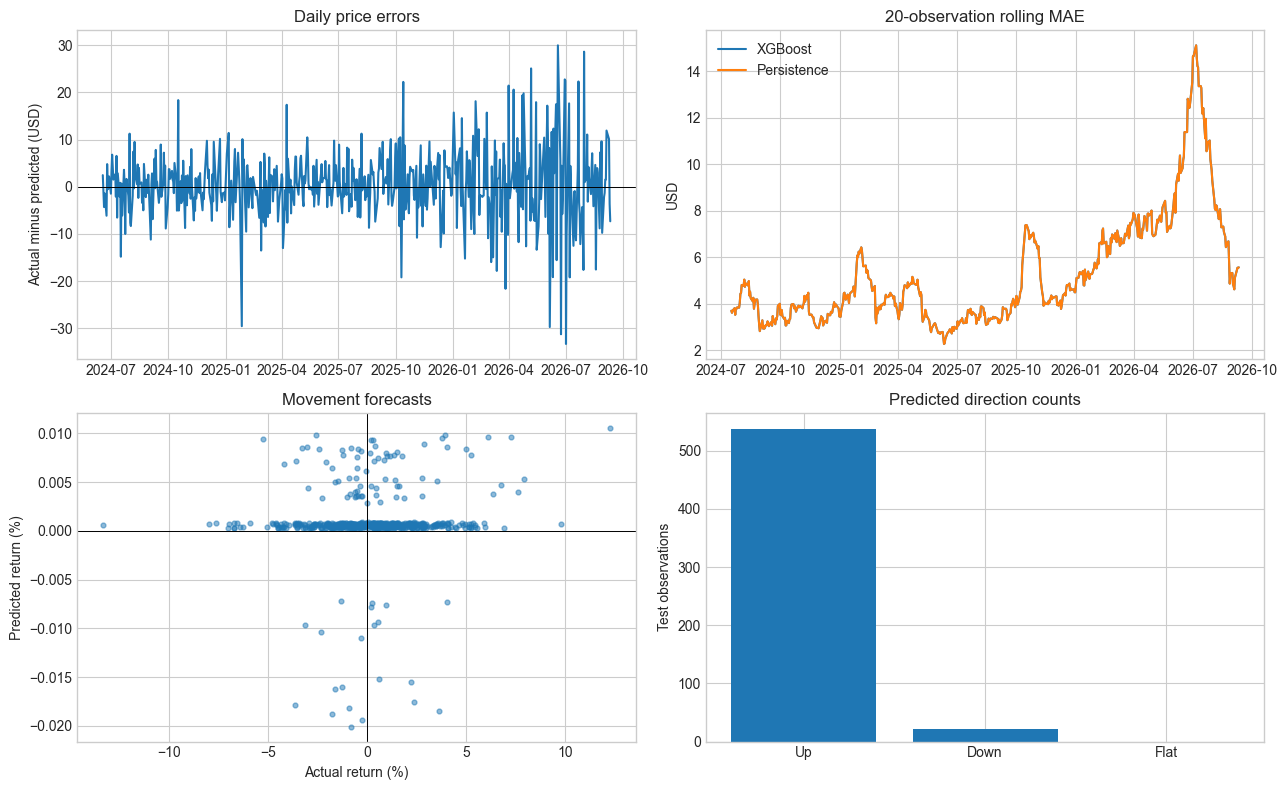

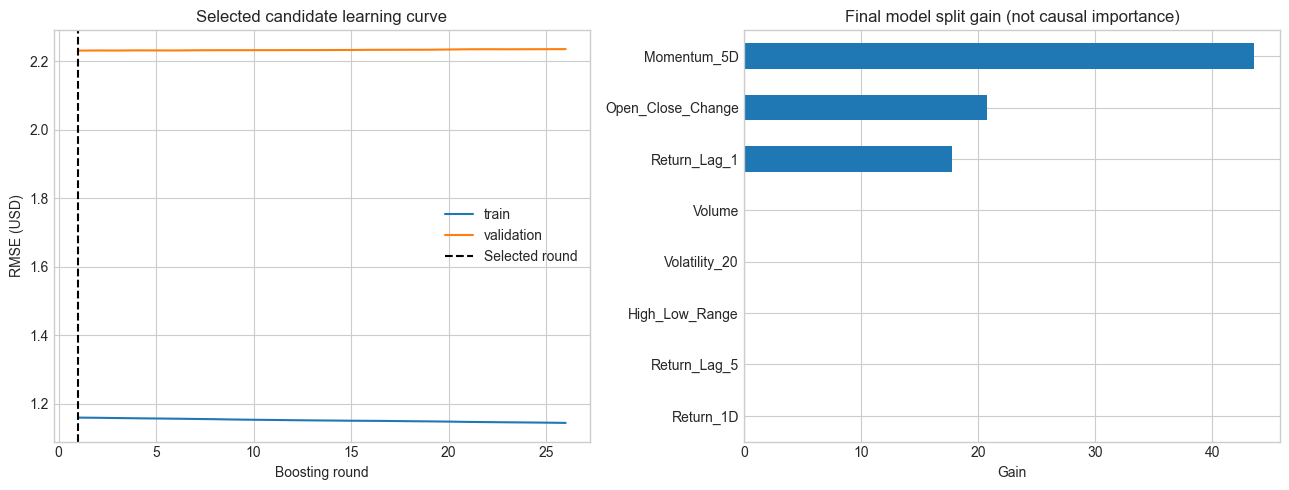

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7))
for ax, frame in [(axes[0], test_export), (axes[1], test_export.tail(90))]:
    ax.plot(frame['Target_Date'], frame['Target_Close'], label='Actual', linewidth=1.2)
    ax.plot(frame['Target_Date'], frame['Prediction'], label='XGBoost', alpha=0.8)
    ax.plot(frame['Target_Date'], frame['Persistence'], label='Persistence', alpha=0.5)
    ax.set_ylabel('USD'); ax.legend()
axes[0].set_title('Test next-day closing prices')
axes[1].set_title('Last 90 test observations')
finish_plot('01_test_prices')

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes[0, 0].plot(test_export['Target_Date'], test_export['Error_actual_minus_predicted'])
axes[0, 0].axhline(0, color='black', linewidth=0.7)
axes[0, 0].set(title='Daily price errors', ylabel='Actual minus predicted (USD)')
for label, pred in [('XGBoost', test_predictions), ('Persistence', test['Close'].to_numpy())]:
    rolling = pd.Series(np.abs(test['Target_Close'].to_numpy() - pred)).rolling(20).mean()
    axes[0, 1].plot(test['Target_Date'], rolling, label=label)
axes[0, 1].set(title='20-observation rolling MAE', ylabel='USD'); axes[0, 1].legend()
axes[1, 0].scatter(test_export['Actual_return'] * 100, test_export['Predicted_return'] * 100,
                   s=12, alpha=0.5)
axes[1, 0].axhline(0, color='black', linewidth=0.7)
axes[1, 0].axvline(0, color='black', linewidth=0.7)
axes[1, 0].set(title='Movement forecasts', xlabel='Actual return (%)', ylabel='Predicted return (%)')
axes[1, 1].bar(['Up', 'Down', 'Flat'], [directions['predicted_up'], directions['predicted_down'], directions['predicted_flat']])
axes[1, 1].set(title='Predicted direction counts', ylabel='Test observations')
finish_plot('02_errors_and_direction')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
curve = curves[str(winner['candidate'])]
for split_name, values in curve.items():
    axes[0].plot(np.arange(1, len(values['rmse']) + 1), values['rmse'], label=split_name)
axes[0].axvline(FINAL_ROUNDS, color='black', linestyle='--', label='Selected round')
axes[0].set(title='Selected candidate learning curve', xlabel='Boosting round', ylabel='RMSE (USD)')
axes[0].legend()
importance.nlargest(12, 'gain').sort_values('gain').plot.barh(x='feature', y='gain', ax=axes[1], legend=False)
axes[1].set(title='Final model split gain (not causal importance)', xlabel='Gain', ylabel='')
finish_plot('03_learning_and_importance')


## 9. Experiment manifest and report-ready interpretation

Record data hash, split dates, complete search, selected features/rounds, GPU configuration, versions and limitations. Only this final completion cell updates `latest_run.json`; interrupted runs remain separate. Tiny differences are descriptive, not evidence of statistical superiority. Earlier project notebooks have already exposed part of this historical test period.


In [9]:
manifest = {
    'run_id': RUN_ID, 'source_file': str(DATA_FILE.relative_to(ROOT)),
    'source_sha256': hashlib.sha256(DATA_FILE.read_bytes()).hexdigest(),
    'raw_rows': len(raw), 'aligned_rows': len(data),
    'splits': json.loads(split_summary.to_json(orient='records', date_format='iso')),
    'feature_sets': FEATURE_SETS, 'excluded': EXCLUDED,
    'price_target': 'Close[t+1]', 'training_target': 'Close[t+1] - Close[t]',
    'forecast_origin': 'After Close[t]', 'preprocessing': preprocessing,
    'common_parameters': COMMON_PARAMS, 'grid': GRID,
    'max_rounds': MAX_ROUNDS, 'early_stopping_patience': PATIENCE,
    'candidate_count': len(records), 'successful_candidates': len(eligible),
    'selection': 'Validation RMSE, MAE, rounds, candidate; validation also selects early stopping.',
    'selected_candidate': str(winner['candidate']), 'selected_parameters': SELECTED_PARAMS,
    'selected_features': SELECTED_FEATURES, 'final_rounds': FINAL_ROUNDS,
    'verified_training_device': verified_device, 'final_fit_seconds': final_seconds,
    'validation_metrics': score(validation, validation_predictions[str(winner['candidate'])], train),
    'validation_persistence_metrics': baseline_validation,
    'test_metrics': json.loads(test_metrics.to_json(orient='index')),
    'test_direction_diagnostics': directions,
    'versions': {'python': platform.python_version(), 'xgboost': xgb.__version__,
                 'numpy': np.__version__, 'pandas': pd.__version__, 'sklearn': sklearn.__version__},
    'xgboost_build': xgb.build_info(),
    'limitations': ['Single stock and historical validation period', 'Small prespecified search; no seed repeats',
                    'Validation reused for early stopping and candidate selection',
                    'Earlier project exposure to part of test period',
                    'Fixed model during test; no profitability evaluation',
                    'Ordinal calendar fields and redundant all-feature inputs',
                    'GPU floating-point reproducibility can vary across hardware/versions'],
}
(RUN_DIR / 'manifest.json').write_text(json.dumps(manifest, indent=2), encoding='utf-8')
m = test_metrics.loc['XGBoost_selected']
summary = f"""# GPU XGBoost experiment results

- Search: {len(records)} candidates, {len(eligible)} successful; three feature sets and four common parameter combinations.
- Selected: **{winner['candidate']}**, {len(SELECTED_FEATURES)} inputs; parameters {SELECTED_PARAMS}; {FINAL_ROUNDS} rounds.
- GPU training verified: **{verified_device}**. Final refit uses train + validation.
- Learns dollar change; forecast is today's Close plus predicted change. No scaling or imputation.
- Validation RMSE: **${winner['RMSE']:.4f}**; persistence **${baseline_validation['RMSE']:.4f}**.
- Test MAE **${m['MAE']:.4f}**, RMSE **${m['RMSE']:.4f}**, MAPE **{m['MAPE_pct']:.3f}%**, R² **{m['R2']:.5f}**.
- Test RMSE improvement over persistence: **{m['RMSE_skill_pct']:.3f}%** (negative means worse).
- Direction accuracy: **{m['Direction_accuracy_pct']:.2f}%**; always-up reference **{directions['always_up_accuracy_pct']:.2f}%**.
- Signals: {directions['predicted_up']} up, {directions['predicted_down']} down, {directions['predicted_flat']} flat.
- Full-test saved-model reload check passed.
- Limitations: bounded search; one validation period reused for selection/stopping; prior exposure to test period; no statistical superiority or profitability established.
"""
(RUN_DIR / 'summary.md').write_text(summary, encoding='utf-8')
(RUN_DIR.parent / 'latest_run.json').write_text(json.dumps({
    'run_id': RUN_ID, 'directory': str(RUN_DIR.relative_to(ROOT))}, indent=2), encoding='utf-8')
display(Markdown(summary))


# GPU XGBoost experiment results

- Search: 12 candidates, 12 successful; three feature sets and four common parameter combinations.
- Selected: **curated_g0**, 8 inputs; parameters {'max_depth': 2, 'eta': 0.03}; 1 rounds.
- GPU training verified: **cuda:0**. Final refit uses train + validation.
- Learns dollar change; forecast is today's Close plus predicted change. No scaling or imputation.
- Validation RMSE: **$2.2318**; persistence **$2.2317**.
- Test MAE **$5.2323**, RMSE **$7.4007**, MAPE **1.968%**, R² **0.99349**.
- Test RMSE improvement over persistence: **0.008%** (negative means worse).
- Direction accuracy: **53.31%**; always-up reference **53.13%**.
- Signals: 538 up, 21 down, 0 flat.
- Full-test saved-model reload check passed.
- Limitations: bounded search; one validation period reused for selection/stopping; prior exposure to test period; no statistical superiority or profitability established.
